<a href="https://colab.research.google.com/github/perekis228/DU/blob/main/01tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание 1. Практическая часть. Производные, интегралы в SymPy

### Пример оформления решения

Подключаем пакеты Python

In [ ]:
from sympy import * # пакет символьных вычислений
import numpy as np # пакет для работы с многомерными массивами

Создаем символы (переменные)

In [ ]:
x, y, t, C = symbols("x y t C")

Теперь можно создавать выражения с этими переменными

In [ ]:
f = x ** 2 - sin(x) / 2 + sqrt(x - 1)
f

x**2 + sqrt(x - 1) - sin(x)/2

Дифференцирование выражений выполняется командой diff

In [ ]:
diff(f, x)

2*x - cos(x)/2 + 1/(2*sqrt(x - 1))

Интегрирование - командой integrate

In [ ]:
integrate(f, x)

x**3/3 + 2*(x - 1)**(3/2)/3 + cos(x)/2

Определенный интеграл вычисляется той же командой, но с указанием во втором аргументе пределов интегрирования

In [ ]:
integrate(f, (x, 2, 5))

cos(5)/2 - cos(2)/2 + 131/3

Решим простейшее дифференциальное уравнение $xy'+2=x^2$ с начальным условием $y(1)=2$

In [ ]:
# создаем производную
dydx = Derivative(y, x) # dydx - имя переменной, обозначающей производную
dydx

Derivative(y, x)

In [ ]:
# создаем уравнение, функция Eq(a, b) обозначает равенство a = b
eq = Eq(x * dydx + 2, x ** 2)
eq

Eq(x*Derivative(y, x) + 2, x**2)

In [ ]:
# находим производную с помощью команды solve - решение алгебраических уравнений, результат - список решений, выбор нужного решения через индексирование
sol = solve(eq, dydx)[0]
sol

x - 2/x

In [ ]:
# интегрируем найденную производную и вручную добавляем константу интегрирования - получаем общее решение заданного ДУ
dsol = integrate(sol, x) + C
dsol

C + x**2/2 - 2*log(x)

In [ ]:
# Находим константу интегрирования, решая уравнение y(x0, C) = y0, где x0, y0 - начальное условие
x0, y0 = 1, 2 # см. условие задачи выше
X = dsol.subs(x, x0) # подставили x0 вместо x в решение dsol
eq = Eq(y0, X) # приравняли к y0
C0 = solve(eq)[0] # нашли С
dsol0 = dsol.subs(C, C0) # подставили C в общее решение
dsol0 # решение начальной задачи

x**2/2 - 2*log(x) + 3/2

Построим графики с интегральными кривыми

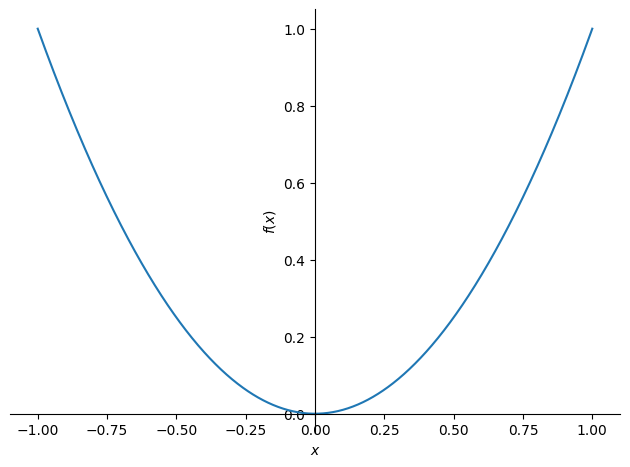

In [ ]:
# график функции f(x) в интервале от a до b строится командой plot( f(x), (x,a,b) )
p = plot(x ** 2, (x, -1, 1))

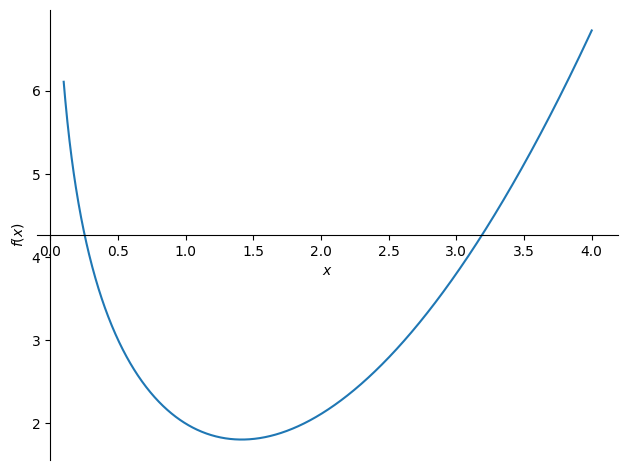

In [ ]:
# график решения dsol0 начальной задачи
p = plot(dsol0, (x, 0.1, 4))

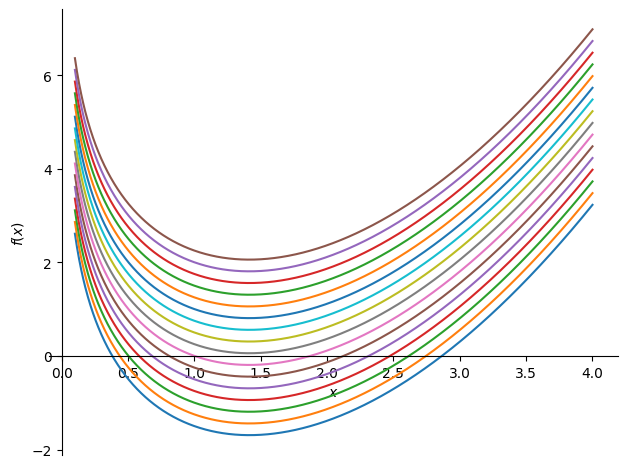

In [ ]:
# график семейства интегральных кривых общего решения dsol
p = plot(show=False) # пустой график
for c in np.arange(-2, 2, 0.25): # цикл по значениям константы C
  p1 = plot(dsol.subs(C, c), (x, 0.1, 4), show=False) # график новой кривой
  p.extend(p1) # добавляем новый график к общему графику
p.show() # показываем общий график

### Задание
По описанной выше схеме для Вашего варианта вычислите производную из пункта (а) аналитической части (задание 1.1)

In [ ]:
from sympy import * # пакет символьных вычислений
import numpy as np # пакет для работы с многомерными массивами

x = symbols("x")
f = x + (cos(x-6))**8 - 1 + sin(cos(x))
diff(f, x)

-sin(x)*cos(cos(x)) - 8*sin(x - 6)*cos(x - 6)**7 + 1

Для Вашего варианта найдите общее решение ДУ из пункта б аналитической части (задание 1.1)

In [ ]:
from sympy import * # пакет символьных вычислений
import numpy as np # пакет для работы с многомерными массивами

x, y, C = symbols("x y C")
dydx = Derivative(y, x)
eq = Eq(dydx, -2*y/x)
sol = solve(eq, dydx)[0]
dsol = integrate(sol, x) + C
print(dsol)

x0, y0 = 1, 4
X = dsol.subs(x, x0)
eq = Eq(y0, X)
C0 = solve(eq)[0]
dsol0 = dsol.subs(C, C0)
dsol0

C - 2*y*log(x)


-2*y*log(x) + 4

Для Вашего варианта найдите решение начальной задачи из пункта б аналитической части (задание 1.1)

## Задание 2. Свободное падение тел

Создаем переменные $x$, $y$, $t$, $w_0$, $\alpha$ и $g$

In [ ]:
x, y, t, w0, a, g = symbols("x y t w0 a g")

Создаем начальные условия $x_0=0$, $y_0=0$, $u_0=w_0\cos{\alpha}$, $v_0=w_0\sin{\alpha}$

In [ ]:
x0 = 0
y0 = 0
u0 = w0
v0 = w0 * sin(a)

Создаем правые части простейших дифференциальных уравнений для горизонтальной и вертикальной скоростей: $$du/dt=0, dv/dt=-g$$

In [ ]:
U = 0
V = -g

Интегрируем эти правые части и находим сами скорости с учетом начальных условий: $$u=\int U dt + u_0, v = \int V dt + v_0$$

In [ ]:
u = integrate(U, t) + u0
v = integrate(V, t) + v0
u, v # выводим на экран найденные интегралы

(w0, -g*t + w0*sin(a))

Получили правые части простейших ДУ для $x(t)$ и $y(t)$: $dx/dt=u$, $dy/dt=v$. Интегрируем эти выражения и находим $x(t)$ и $y(t)$ с учетом начальных условий: $$x=\int u dt + x_0, y=\int v dt + y0$$

In [ ]:
xsol = integrate(u, t) + x0
ysol = integrate(v, t) + y0
xsol, ysol # выводим на экран найденные интегралы

(t*w0, -g*t**2/2 + t*w0*sin(a))

Вычисляем время $t_1$ от начала полета до падения, решая уравнение $y(t)=0$. Выражение $y(t)$ хранится в переменной ysol. Данное уравнение имеет два решения, нужно записать в переменную t1 ненулевое решение.

In [ ]:
t1 = solve(Eq(ysol, 0), t)[1]
t1 # вывод на экран

2*w0*sin(a)/g

Находим $x$-координату точки падения, подставляя найденное выше значение $t_1$ в выражение $x(t)$ (переменная xsol):

In [ ]:
x1 = xsol.subs(t, t1)
x1 # вывод на экран

2*w0**2*sin(a)/g

Выражаем $y$ через $x$, исключая из системы $x(t)=0$, $y(t)=0$ время $t$:

In [ ]:
T = solve(Eq(xsol, x), t)[0] # выразили t через x
Y = ysol.subs(t, T) # подставили T в y(t) вместо t
Y # вывод формулы на экран

-g*x**2/(2*w0**2) + x*sin(a)

Строим траекторию движения тела от точки броска $x=0$ до точки падения $x=x_1$ для ускорения свободного падения $g=9.8$, начальной скорости $w_0=1$, угла $\alpha=\pi/4$:

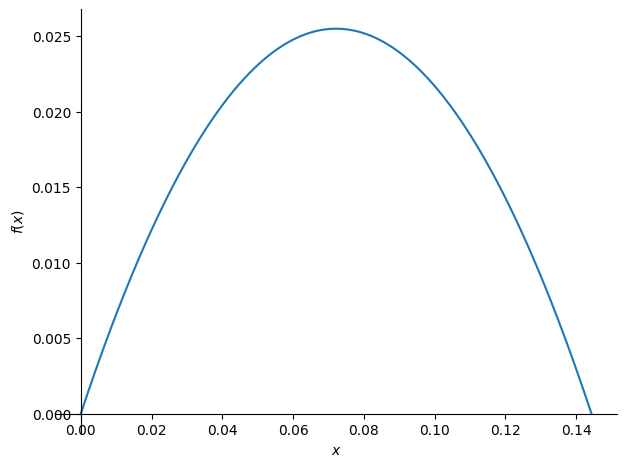

In [ ]:
ya = Y.subs(g, 9.8).subs(w0, 1).subs(a, np.pi/4) # уравнение траектории
x1a = x1.subs(g, 9.8).subs(w0, 1).subs(a, np.pi/4) # точка падения
p = plot(ya, (x, 0, x1a))

Постройте на том же графике аналогичную траекторию полета тела на заданном космическом теле (ускорение свободного падения для этого тела найдите в Интернете):
1. Луна
2. Марс

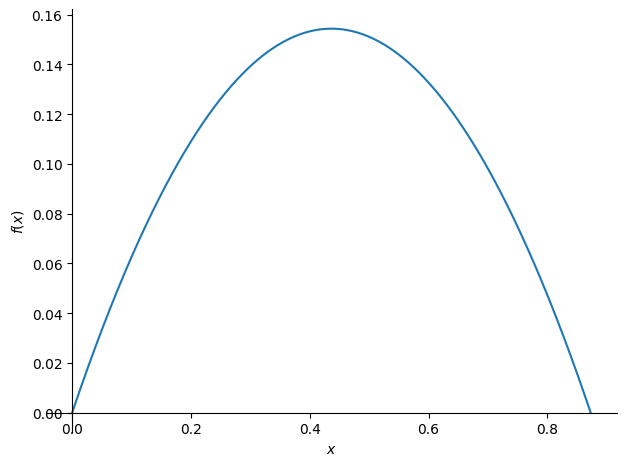

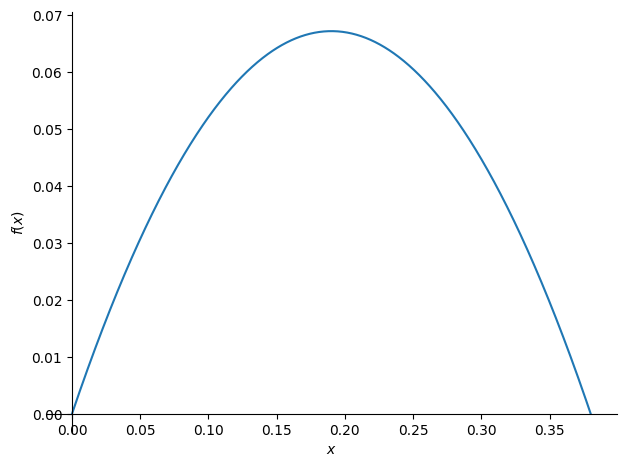

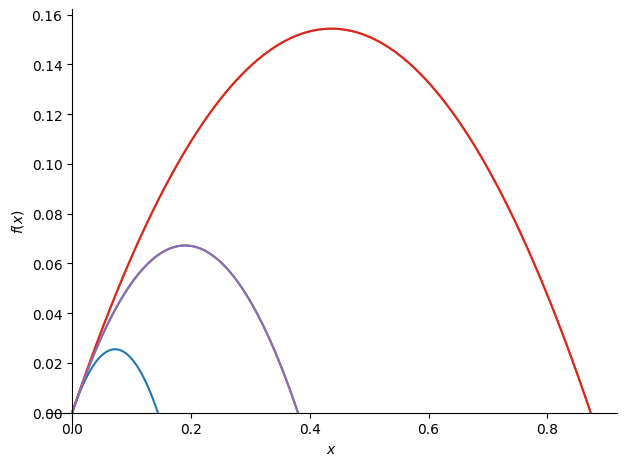

In [ ]:
#Luna
ya = Y.subs(g, 1.62).subs(w0, 1).subs(a, np.pi/4) # уравнение траектории
x1a = x1.subs(g, 1.62).subs(w0, 1).subs(a, np.pi/4) # точка падения
p1 = plot(ya, (x, 0, x1a))
p.extend(p1)

#Mars
ya = Y.subs(g, 3.72).subs(w0, 1).subs(a, np.pi/4) # уравнение траектории
x1a = x1.subs(g, 3.72).subs(w0, 1).subs(a, np.pi/4) # точка падения
p2 = plot(ya, (x, 0, x1a))
p.extend(p2)

p.show()

## Задание 3. Свободное падение тел, семейство траекторий

Постройте семейство траекторий для разных начальных углов $\alpha\in[\pi/20, \pi/2]$ с шагом $\pi/20$ для вашего космического тела:

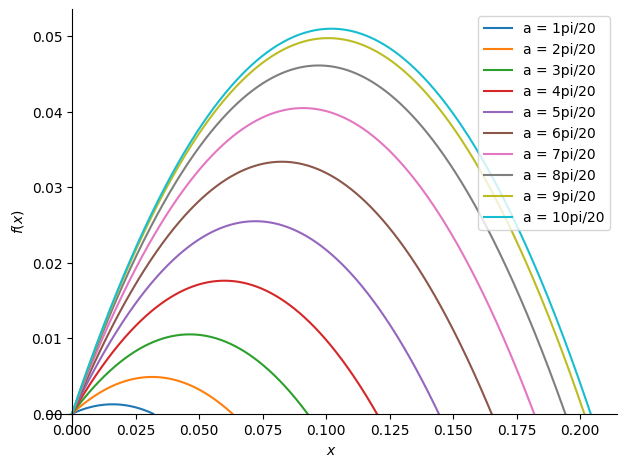

In [ ]:
plots_list = []
for i in range(1, 11):
    a_val = i * pi / 20
    ya = Y.subs(g, 9.8).subs(w0, 1).subs(a, a_val).evalf()
    x1a = float(x1.subs(g, 9.8).subs(w0, 1).subs(a, a_val))
    plots_list.append((ya, (x, 0, x1a)))

p = plot(*plots_list, show=False, legend=True)

for i, line in enumerate(p):
    line.label = f"a = {i+1}pi/20"

p.show()

Постройте семейство траекторий для разных начальных скоростей $w_0\in[1,10]$ с шагом $1$ для вашего космического тела

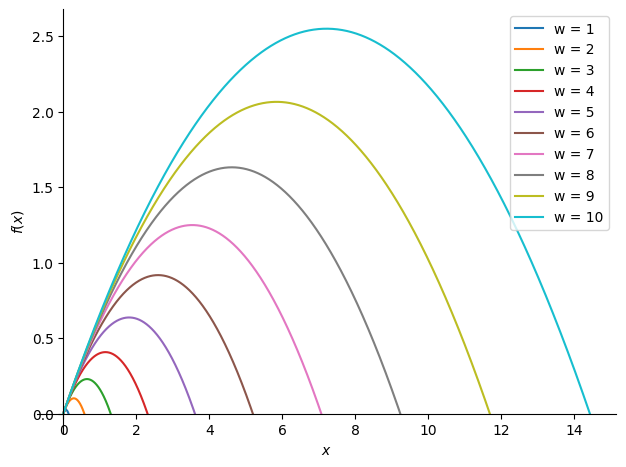

In [ ]:
plots_list = []
for w in range(1, 11):
    ya = Y.subs(g, 9.8).subs(w0, w).subs(a, np.pi/4).evalf()
    x1a = float(x1.subs(g, 9.8).subs(w0, w).subs(a, np.pi/4))
    plots_list.append((ya, (x, 0, x1a)))

p = plot(*plots_list, show=False, legend=True)

for i, line in enumerate(p):
    line.label = f"w = {i+1}"

p.show()

## Задание 4. Свободное падение балласта

С воздушного шара, который спускается вертикально вниз со скоростью 10 м/с, на высоте 1000 метров сбрасывают алюминиевый балласт массой 10 кг. После сброса на балласт действует сила сопротивления воздуха, пропорциональная его скорости, с коэффициентом сопротивления $k = 5.0$ кг/c. Через 40 секунд на высоте 500 метров был сброшен второй свинцовый балласт массой в 4 раза больше алюминиевого с тем же коэффициентом сопротивления. Какой из балластов достигнет поверхности Земли раньше и с какой разницей по времени, если скорость спуска воздушного шара на высоте 500 метров при сбросе второго балласта составила 1 м/с. Ускорение свободного падения считать равным 10 м/$с^2$. Приведите графики изменения скорости с течением времени для каждого балласта.

In [36]:
from sympy import *
t, C1 = symbols("t C1")
v = Function('v')(t)
s = Function('s')(t)

k = 5
g = 10
v0_al = 10
m_al = 10
v0_pb = 1
m_pb = 40
t0 = 0
t1 = 40
s0 = 0
s1 = 500

In [53]:
#Al
eq_al = Eq(m_al*Derivative(v, t), -k*v + m_al*g)
dsol_al = dsolve(eq_al, v)
eq_al_c = Eq(v0_al, dsol_al.rhs.subs(t, t0))
C = solve(eq_al_c, C1)[0]
final_solution_al = dsol_al.subs(C1, C)
pprint(final_solution_al)

eq = Eq(Derivative(s, t), final_solution_al.rhs)
dsol = dsolve(eq, s)
eq_c = Eq(s0, dsol.rhs.subs(t, t0))
C = solve(eq_c, C1)[0]
final_sol = dsol.subs(C1, C)
pprint(final_sol)

t_land_al = solve(Eq(final_sol.rhs, 1000), t)[0]
t_land_al = N(t_land_al, 20)
t_land_al

                -t 
                ───
                 2 
v(t) = 20 - 10⋅ℯ   
                       -t 
                       ───
                        2 
s(t) = 20⋅t - 20 + 20⋅ℯ   


50.999999999991576536

In [56]:
#Pb
eq_pb = Eq(m_pb*Derivative(v, t), - k*v + m_pb*g)
dsol_pb = dsolve(eq_pb, v)
eq_pb_c = Eq(v0_pb, dsol_pb.rhs.subs(t, t0))
C = solve(eq_pb_c, C1)[0]
final_solution_pb = dsol_pb.subs(C1, C)
pprint(final_solution_pb)

eq = Eq(Derivative(s, t), final_solution_pb.rhs)
dsol = dsolve(eq, s)
eq_c = Eq(s0, dsol.rhs.subs(t, t0))
C = solve(eq_c, C1)[0]
final_sol = dsol.subs(C1, C)
pprint(final_sol)

t_land_pb = nsolve(Eq(final_sol.rhs, 500), 40)
t_land_pb += 40
t_land_pb

                -t 
                ───
                 8 
v(t) = 80 - 79⋅ℯ   
                         -t 
                         ───
                          8 
s(t) = 80⋅t - 632 + 632⋅ℯ   


52.4925212902652

In [57]:
#Diff
t_diff = t_land_al - t_land_pb
if t_diff < 0:
  print(f"Алюминиевый шар приземлился быстрее свинцового на {-t_diff} c")
elif t_diff > 0:
  print(f"Свинцовый шар приземлился быстрее алюминиевого на {t_diff} c")
else:
  print(f"Шары приземлились одновременно")

Алюминиевый шар приземлился быстрее свинцового на 1.4925212902736397576 c


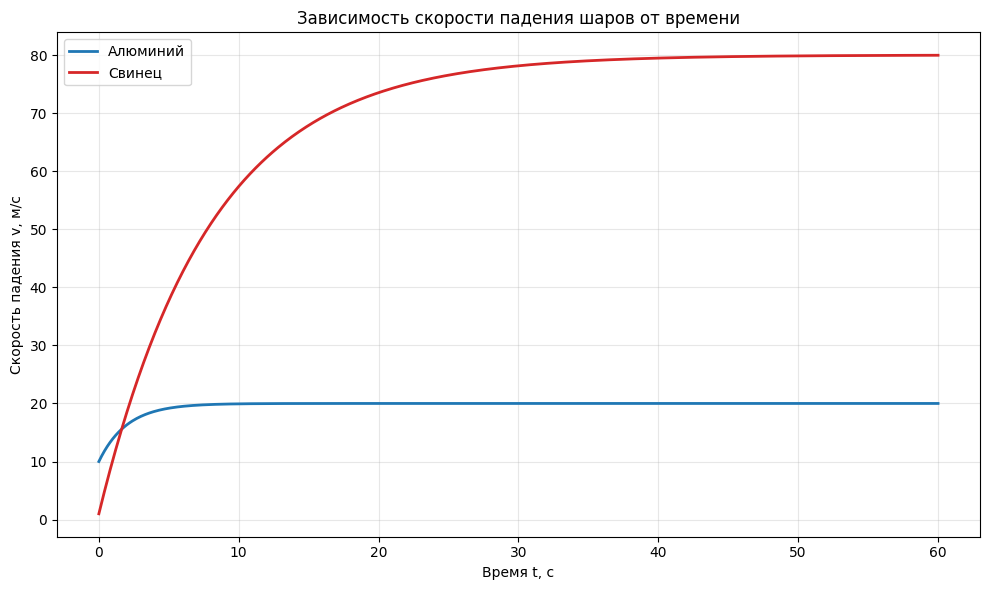

In [61]:
#Graph
import matplotlib.pyplot as plt
import numpy as np

v_al = final_solution_al.rhs
v_pb = final_solution_pb.rhs

v_al_num = lambdify(t, v_al, 'numpy')
v_pb_num = lambdify(t, v_pb, 'numpy')

T = np.linspace(0, 60, 600)

plt.figure(figsize=(10, 6))
plt.plot(T, v_al_num(T), label='Алюминий', color='tab:blue', linewidth=2)
plt.plot(T, v_pb_num(T), label='Свинец', color='tab:red', linewidth=2)

plt.xlabel('Время t, с')
plt.ylabel('Скорость падения v, м/с')
plt.title('Зависимость скорости падения шаров от времени')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Задание 5. Представление вещественных чисел

0 − 0101 − 01000 \
0 - положительное \
0101 = 5 \
01000 = 0.25 \
(-1)^0 * 2^5 * (1+0.25) = 1 * 32 * 1.25 = 40 \
Ответ: 40